In [15]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm 
from rpy2.robjects.packages import importr
import rpy2.robjects as robjects

from scipy.stats import shapiro
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score


In [16]:
# Load data
df12 = pd.read_csv('election_data_2012.csv')

In [17]:
# Verify format
df12.head(5)

,Estado,Municipio,Parroquia,Chavez,Radonski,Sequera,Bolivar,Reyes,Chirino,Valid,Invalid,Total
0,Amazonas,Alto Orinoco,Huachamacare,281,168,9,0,1,0,459,2,461
1,Amazonas,Alto Orinoco,La Esmeralda,474,233,13,0,0,0,720,15,735
2,Amazonas,Alto Orinoco,Marawaka,344,348,8,0,0,0,700,55,755
3,Amazonas,Alto Orinoco,Mavaca,825,335,4,1,0,0,1165,10,1175
4,Amazonas,Alto Orinoco,Sierra Parima,220,25,1,0,0,0,246,3,249


In [18]:
# Create Validation Rate and Support Rate features

df12["ValidRate"] = df12["Valid"] / df12["Total"]
candidates = ['Chavez', 'Radonski', 'Sequera', 'Bolivar', 'Reyes', 'Chirino']
candidateRates = []
for candidate in candidates:
    csr = candidate + 'SR'
    if candidate not in df12.columns:
        continue
    if csr in df12.columns:
        continue
    df12[csr] = df12[candidate] / df12["Valid"]
    candidateRates.append(candidate + 'SR')


In [20]:
# Normality checks for support rates
# Obviously some were not normal, but passed the normality check, to be expected for low performing candidates

for rate in candidateRates:
    candidate = rate[:-2]  # Remove 'SR' from the column name to get the candidate's name
    stat, pval = shapiro(df12[rate])
    print(f'Shapiro-Wilk test for {candidate}:')
    print(f'Statistic: {stat}, p-value: {pval}\n')
print(sm.families)

Shapiro-Wilk test for Chavez:
Statistic: 0.9811043664973019, p-value: 5.402693415341619e-11

Shapiro-Wilk test for Radonski:
Statistic: 0.9806139915144989, p-value: 3.538778399641938e-11

Shapiro-Wilk test for Sequera:
Statistic: 0.7738831364930254, p-value: 6.89559272934073e-37

Shapiro-Wilk test for Bolivar:
Statistic: 0.8436994766452829, p-value: 5.378347571049889e-32

Shapiro-Wilk test for Reyes:
Statistic: 0.8365423120340045, p-value: 1.435191664887165e-32

Shapiro-Wilk test for Chirino:
Statistic: 0.532328177201246, p-value: 1.3988477248450158e-47

<module 'statsmodels.genmod.families' from '/Users/james/.pyenv/versions/3.11.8/lib/python3.11/site-packages/statsmodels/genmod/families/__init__.py'>


<Axes: xlabel='ChavezSR', ylabel='ValidRate'>

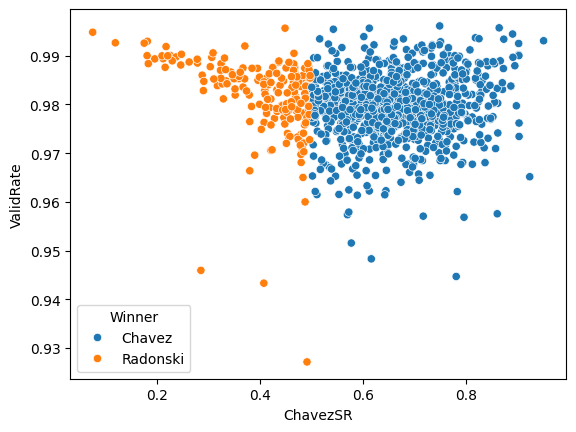

In [22]:
# Scatterplot displaying validation rate on y axis, Chavez (winner) on x-axis, color based on who won each region
df12['Winner'] = df12[candidates].idxmax(axis=1)
sns.scatterplot(data=df12, x='ChavezSR', y='ValidRate', hue='Winner')

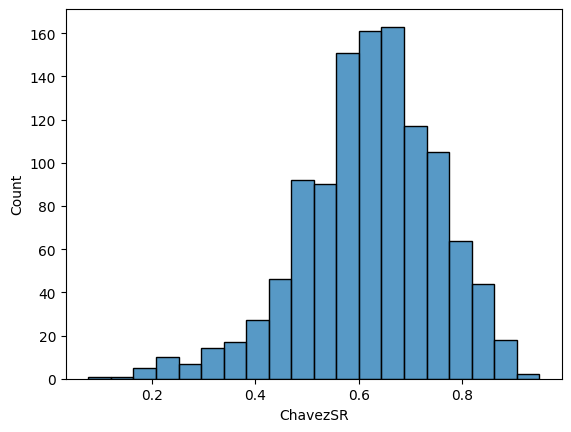

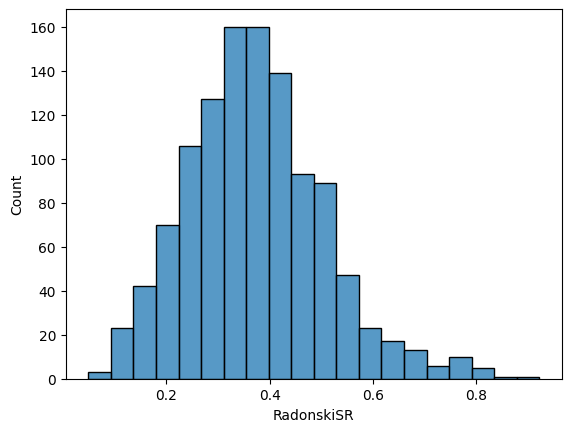

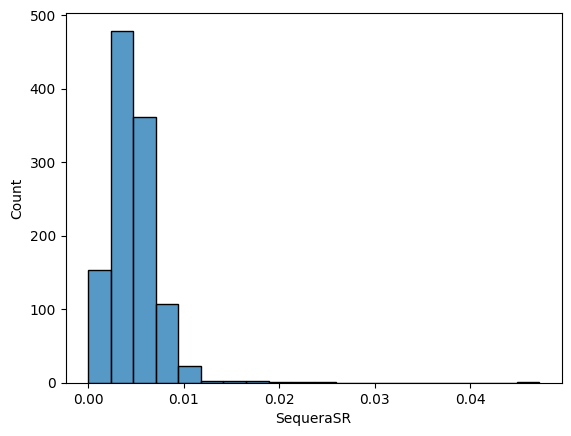

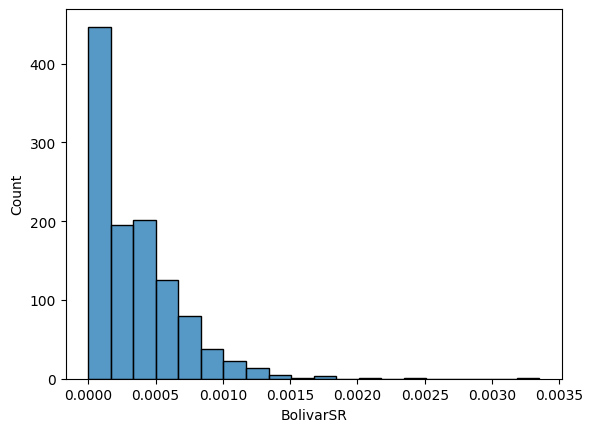

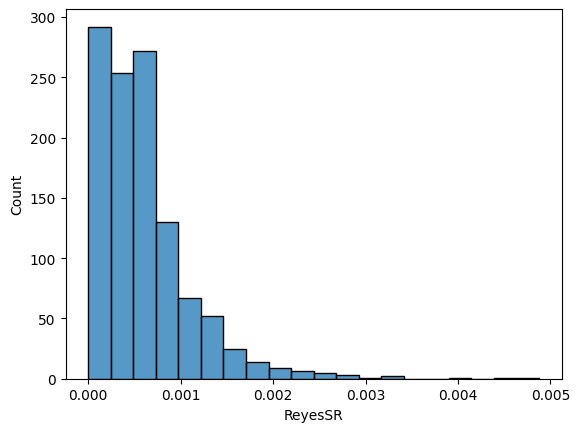

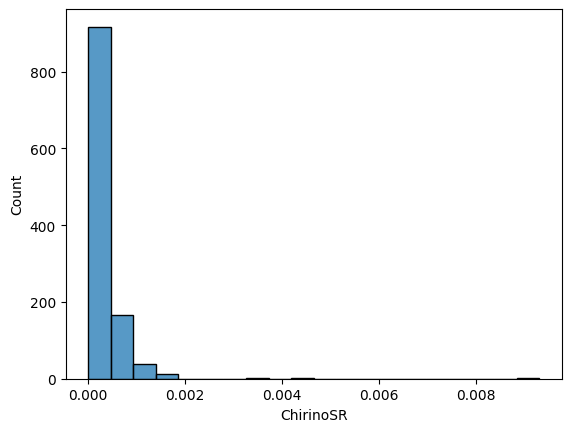

In [23]:
# Plot support rates for eyeball normality checks, some fail due to low support
for rate in candidateRates:
    plt.figure()
    sns.histplot(df12[rate], bins=20)

<Axes: xlabel='ValidRate', ylabel='Count'>

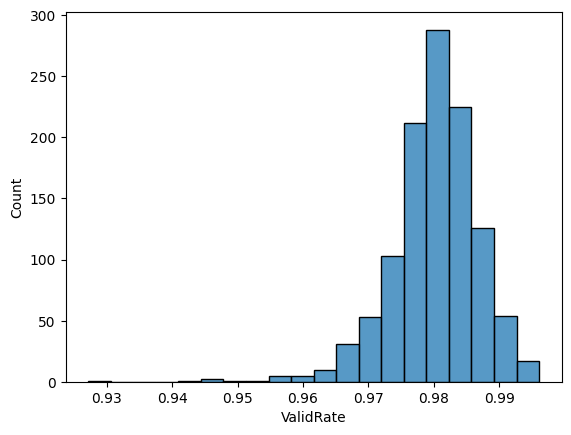

In [24]:
# Normality check for validation rate, slight left skew

sns.histplot(df12['ValidRate'], bins=20)

In [26]:
# Fit a GLM for each candidate
models = {}
for candidate in candidates:
    csr = candidate + 'SR'
    X = sm.add_constant(df12[csr])
    y = df12['ValidRate']
    model = sm.GLM(y, X, family=sm.families.InverseGaussian()).fit()
    models[candidate] = model

# Display the results

for candidate in candidates:
    print(candidate)
    model = models[candidate]
    print(model.summary())
    print()

Chavez
                 Generalized Linear Model Regression Results                  
Dep. Variable:              ValidRate   No. Observations:                 1135
Model:                            GLM   Df Residuals:                     1133
Model Family:         InverseGaussian   Df Model:                            1
Link Function:         InverseSquared   Scale:                      4.9012e-05
Method:                          IRLS   Log-Likelihood:                 4051.1
Date:                Mon, 23 Feb 2026   Deviance:                     0.056047
Time:                        23:00:51   Pearson chi2:                   0.0555
No. Iterations:                     5   Pseudo R-squ. (CS):           0.005670
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0359      0.002    502.808  

Validation rates seem to benefit all but Radonski, but low pseudo R squared indicate a pretty bad fit for most models, better fitted model to be pursued 

In [27]:

X = sm.add_constant(df12[candidateRates])
y = df12['ValidRate']
model = sm.GLM(y, X, family=sm.families.Gaussian()).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              ValidRate   No. Observations:                 1135
Model:                            GLM   Df Residuals:                     1129
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                      4.1487e-05
Method:                          IRLS   Log-Likelihood:                 4118.7
Date:                Mon, 23 Feb 2026   Deviance:                     0.046839
Time:                        23:00:51   Pearson chi2:                   0.0468
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1149
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5139      0.106      4.860      0.000       0.307       0.721
ChavezSR       0.4691      0.106      4.425      0.000       0.261       0.677
RadonskiSR     0.4726      0.106      4.460      0.000       0.265       0.680
SequeraSR     -0.2856      0.133     -2.149      0.032      -0.546      -0.025
BolivarSR     -0.5348      0.499     -1.073      0.283      -1.512       0.442
ReyesSR       -0.0657      0.338     -0.194      0.846      -0.729       0.597
ChirinoSR      0.4583      0.411      1.114      0.265      -0.348       1.265
==============================================================================
"""

In [29]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import rpy2.robjects.packages as rpackages

# Import R's 'utils' package to handle installations
utils = importr('utils')

# Select a mirror and install VGAM
utils.chooseCRANmirror(ind=1) # Selects the first available mirror
utils.install_packages('VGAM')
vgam = importr('VGAM')

# Use the localconverter context to safely transform your pandas DataFrame (df18)
with localconverter(robjects.default_converter + pandas2ri.converter):
    r_data = robjects.conversion.py2rpy(df12)

# Verification
print(f"R object type: {type(r_data)}")
print(f"Column names: {r_data.names}")

R callback write-console: trying URL 'https://cloud.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/VGAM_1.1-14.tgz'
  
R callback write-console: Content type 'application/x-gzip'  
R callback write-console:  length 8137070 bytes (7.8 MB)
  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R callback write-console: =  
R cal


The downloaded binary packages are in
	/var/folders/sl/4g_r_0yn3lj90f8gs0fxhkwm0000gn/T//RtmpT1QypD/downloaded_packages
R object type: <class 'rpy2.robjects.vectors.DataFrame'>
Column names:  [1] "Estado"     "Municipio"  "Parroquia"  "Chavez"     "Radonski"  
 [6] "Sequera"    "Bolivar"    "Reyes"      "Chirino"    "Valid"     
[11] "Invalid"    "Total"      "ValidRate"  "ChavezSR"   "RadonskiSR"
[16] "SequeraSR"  "BolivarSR"  "ReyesSR"    "ChirinoSR"  "Winner"    



In [30]:
robjects.globalenv['r_data'] = r_data


# Load the VGAM package
VGAM = importr('VGAM')

# R code
rCodeFit = ('''
library(VGAM)
fit <- vglm(cbind(Valid, Invalid) ~ ChavezSR, betabinomial, data = r_data)
print(summary(fit))
''')

rCodePredict = '''
predicted <- predict(fit, type = "response")
predicted
'''

RrCodeFit = ('''
library(VGAM)
fit <- vglm(cbind(Valid, Invalid) ~ RadonskiSR, betabinomial, data = r_data)
print(summary(fit))
''')

RrCodePredict = '''
predicted <- predict(fit, type = "response")
predicted
'''


In [31]:
summary = robjects.r(rCodeFit)
predicted = robjects.r(rCodePredict)



Call:
vglm(formula = cbind(Valid, Invalid) ~ ChavezSR, family = betabinomial, 
    data = r_data)

Coefficients: 
              Estimate Std. Error  z value Pr(>|z|)    
(Intercept):1  4.10339    0.04419   92.866  < 2e-16 ***
(Intercept):2 -6.44194    0.04931 -130.654  < 2e-16 ***
ChavezSR      -0.33409    0.06966   -4.796 1.62e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Names of linear predictors: logitlink(mu), logitlink(rho)

Log-likelihood: -5644.064 on 2267 degrees of freedom

Number of Fisher scoring iterations: 9 



Type 1 error, p value <0.05 indicates we should reject, however alternative hypothesis is looking for a positive slope, which would indicate vote invalidation in favor of the winning candidate, not against. Thus, no statistically significant evidence that differential invalidation was used in favor of winning candidate.

In [32]:
df12['ChavezPredicted'] = np.array(predicted) * 100

pltdf = df12.sort_values('Total', ascending=True)
pltdf.head(5)

,Estado,Municipio,Parroquia,Chavez,Radonski,Sequera,Bolivar,Reyes,Chirino,Valid,...,Total,ValidRate,ChavezSR,RadonskiSR,SequeraSR,BolivarSR,ReyesSR,ChirinoSR,Winner,ChavezPredicted
26,Amazonas,Rio Negro,Cocuy,24,61,1,0,0,0,86,...,87,0.988506,0.279070,0.709302,0.011628,0.0,0.0,0.0,Radonski,98.219221
25,Amazonas,Rio Negro,Casiquiare,46,78,0,0,0,0,124,...,125,0.992000,0.370968,0.629032,0.000000,0.0,0.0,0.0,Radonski,98.164718
22,Amazonas,Maroa,Comunidad,94,34,0,0,0,0,128,...,129,0.992248,0.734375,0.265625,0.000000,0.0,0.0,0.0,Chavez,97.932699
5,Amazonas,Atabapo,Caname,76,63,0,0,0,0,139,...,144,0.965278,0.546763,0.453237,0.000000,0.0,0.0,0.0,Chavez,98.055859
378,Falcon,Democracia,Agua Clara,112,97,2,0,0,0,211,...,214,0.985981,0.530806,0.459716,0.009479,0.0,0.0,0.0,Chavez,98.065996


/Users/james/.pyenv/versions/3.11.8/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


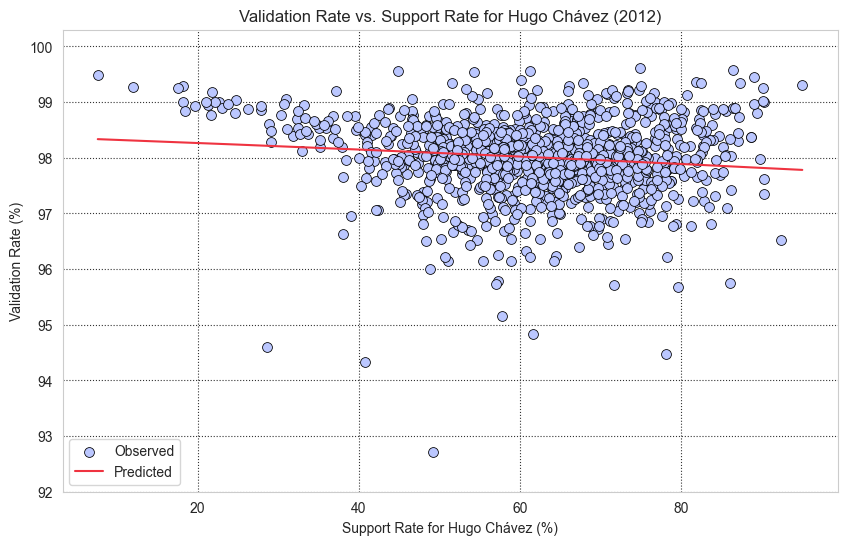

In [33]:
red = (0.9372549019607843, 0.2, 0.25098039215686274)
norm = Normalize(df12['ValidRate'].min(), df12['ValidRate'].max())
blue = (0, 0.1411764705882353, 0.49019607843137253)

x = 225
minblue = (165/x, 176/x, 1)

norm = LogNorm(vmin = 10, vmax = 150000)
blues_cmap = LinearSegmentedColormap.from_list("custom_blues", [minblue, blue])

pltdf["ValidPercent"] = df12["ValidRate"] * 100
pltdf["ChavezPercent"] = df12["ChavezSR"] * 100

# Plot the data and the regression line
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {"grid.color": ".2", "grid.linestyle": ":"})
sns.scatterplot(x='ChavezPercent', y='ValidPercent', label = 'Observed', data=pltdf, color = minblue, edgecolor = 'black', s=50, norm = norm, legend = False) 
sns.lineplot(x='ChavezPercent', y='ChavezPredicted', data=pltdf, color = red, label='Predicted')
plt.xlabel('Support Rate for Hugo Chávez (%)')
plt.ylabel('Validation Rate (%)')
plt.title('Validation Rate vs. Support Rate for Hugo Chávez (2012)')
plt.ylim(92, 100.3)

# Show the plot
plt.show()